<a href="https://colab.research.google.com/github/MSIDIQ472/MUHAMMAD-SIDIQ_2411533011__ML2526/blob/main/TugasCrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [3]:
dataset_url = 'http://raw.githubusercontent.com/MSIDIQ472/MUHAMMAD-SIDIQ_2411533011__ML2526/refs/heads/main/Praktikum5/gender_submission.csv'
df = pd.read_csv(dataset_url)

dataset_url = 'http://raw.githubusercontent.com/MSIDIQ472/MUHAMMAD-SIDIQ_2411533011__ML2526/refs/heads/main/Praktikum5/test.csv'
df = pd.read_csv(dataset_url)

dataset_url = 'http://raw.githubusercontent.com/MSIDIQ472/MUHAMMAD-SIDIQ_2411533011__ML2526/refs/heads/main/Praktikum5/train.csv'
df = pd.read_csv(dataset_url)

df = df.drop(['Name', 'Ticket', 'Cabin'], axis=1)
df = df.dropna()

df = pd.get_dummies(df, drop_first=True)

X = df.drop('Survived', axis=1)
y = df['Survived']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("RMSE Train:", rmse_train)
print("RMSE Test:", rmse_test)

RMSE Train: 0.0
RMSE Test: 0.4424976788687098


In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = RandomForestClassifier()

scores = cross_val_score(
    model, X, y,
    scoring='neg_mean_squared_error',
    cv=kf
)

rmse_scores = np.sqrt(-scores)

print("RMSE tiap fold:", rmse_scores)
print("RMSE rata-rata:", rmse_scores.mean())

RMSE tiap fold: [0.4503301  0.44249768 0.41959068 0.40245724 0.45963856]
RMSE rata-rata: 0.4349028526474603


In [6]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.78      0.90      0.84        80
           1       0.84      0.68      0.75        63

    accuracy                           0.80       143
   macro avg       0.81      0.79      0.80       143
weighted avg       0.81      0.80      0.80       143



In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ======================
# LOAD DATA
# ======================
dataset_url = 'http://raw.githubusercontent.com/MSIDIQ472/MUHAMMAD-SIDIQ_2411533011__ML2526/refs/heads/main/Praktikum5/train.csv'
df = pd.read_csv(dataset_url)

# ======================
# PREPROCESSING
# ======================
df = df.drop(['Name', 'Ticket', 'Cabin'], axis=1)
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Survived', axis=1)
y = df['Survived']

# ======================
# HOLDOUT VALIDATION
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediksi
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== HOLDOUT VALIDATION ===")
print("Accuracy Train:", train_acc)
print("Accuracy Test :", test_acc)

# ======================
# ANALISIS OVERFITTING / UNDERFITTING
# ======================
gap = train_acc - test_acc

print("\n=== ANALISIS ===")
if gap > 0.1:
    print("Model mengalami OVERFITTING")
elif train_acc < 0.7 and test_acc < 0.7:
    print("Model mengalami UNDERFITTING")
else:
    print("Model cukup baik (fit)")

# ======================
# K-FOLD CROSS VALIDATION
# ======================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model, X, y,
    cv=kf,
    scoring='accuracy'
)

print("\n=== K-FOLD CROSS VALIDATION ===")
print("Accuracy tiap fold:", cv_scores)
print("Rata-rata Accuracy:", cv_scores.mean())
print("Std Dev (stabilitas):", cv_scores.std())

# ======================
# ANALISIS STABILITAS
# ======================
print("\n=== ANALISIS K-FOLD ===")
if cv_scores.std() < 0.02:
    print("Model sangat stabil")
elif cv_scores.std() < 0.05:
    print("Model cukup stabil")
else:
    print("Model kurang stabil")

=== HOLDOUT VALIDATION ===
Accuracy Train: 1.0
Accuracy Test : 0.8181818181818182

=== ANALISIS ===
Model mengalami OVERFITTING

=== K-FOLD CROSS VALIDATION ===
Accuracy tiap fold: [0.81118881 0.7972028  0.80985915 0.86619718 0.79577465]
Rata-rata Accuracy: 0.8160445188614203
Std Dev (stabilitas): 0.025857318106969826

=== ANALISIS K-FOLD ===
Model cukup stabil


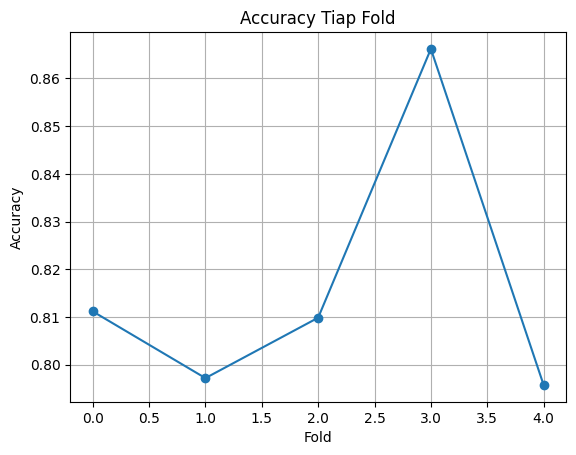

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(cv_scores, marker='o')
plt.title("Accuracy Tiap Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_scores = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')

print("=== PERBANDINGAN MODEL ===")
print("Random Forest Mean Accuracy :", rf_scores.mean())
print("Logistic Regression Mean Accuracy :", lr_scores.mean())

=== PERBANDINGAN MODEL ===
Random Forest Mean Accuracy : 0.7838471387767163
Logistic Regression Mean Accuracy : 0.7836993991923569


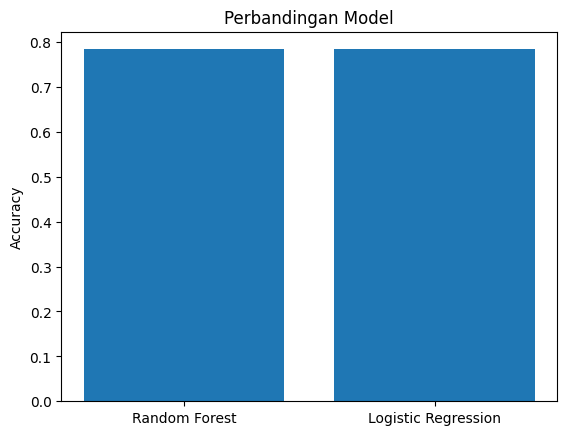

In [11]:
models = ['Random Forest', 'Logistic Regression']
scores = [rf_scores.mean(), lr_scores.mean()]

plt.figure()
plt.bar(models, scores)
plt.title("Perbandingan Model")
plt.ylabel("Accuracy")
plt.show()

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X, y)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy  :", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best Accuracy  : 0.7950753471880233


In [13]:
best_model = grid.best_estimator_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("=== HASIL SETELAH TUNING ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== HASIL SETELAH TUNING ===
Accuracy: 0.7972027972027972

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.90      0.83        80
           1       0.84      0.67      0.74        63

    accuracy                           0.80       143
   macro avg       0.81      0.78      0.79       143
weighted avg       0.80      0.80      0.79       143

